# Endo-FM on PitVis-2023

Frozen-backbone linear probe for step (multi-class) and instrument
(2 slot-columns, multi-class each) recognition, endoscopic pituitary
surgery. Same methodology as the Kvasir-Capsule / Cholec80 notebooks.
No known Endo-FM pretraining overlap for this dataset.

Split below is a simple video-level holdout (last 5 of 25 videos as test)
-- **not verified against the official PitVis Challenge split**, since that
hasn't been pulled from the challenge materials. Will need to `TEST_VIDEO_IDS`.

## 0. Setup

In [ ]:

import sys, subprocess, random, re, json
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/endofm-benchmark")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "einops", "timm", "gdown", "opencv-python-headless"], check=True)
else:
    PROJECT_ROOT = Path(r"E:/endofm-benchmark")




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
VIDEOS_DIR = PROJECT_ROOT / "data" / "pitvis" / "raw" / "videos"
ANNOT_DIR = PROJECT_ROOT / "data" / "pitvis" / "raw" / "annotations"
FRAMES_DIR = PROJECT_ROOT / "data" / "pitvis" / "extracted_frames"
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

ENDOFM_REPO = PROJECT_ROOT / "Endo-FM"
CKPT_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results" / "pitvis"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ENDOFM_REPO))

import torch
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(0)
torch.manual_seed(0)

torch: 2.11.0+cu128 | CUDA: True


## 1. Backbone

In [ ]:
VIDEOS_DIR

PosixPath('/content/drive/MyDrive/endofm-benchmark/data/pitvis/raw/videos')

In [ ]:

if not (ENDOFM_REPO / "models" / "timesformer.py").exists():
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/med-air/Endo-FM.git", str(ENDOFM_REPO)], check=True)

CKPT_PATH = CKPT_DIR / "endo_fm.pth"
if not CKPT_PATH.exists():
    import gdown
    gdown.download(id="1H7B91Ewm4QkZRsnUk1Bn0IQch5P8C7Xl", output=str(CKPT_PATH), quiet=False)


## 2. Discover videos + annotations

In [ ]:

def video_id_from_path(p):
    m = re.search(r"(\d+)", p.stem)
    return int(m.group(1)) if m else None

video_paths = list(VIDEOS_DIR.glob("*.mp4"))
annot_paths = [p for p in ANNOT_DIR.glob("*.csv") if re.search(r"annotations", p.name, re.IGNORECASE)]

video_id_to_path = {video_id_from_path(p): p for p in video_paths if video_id_from_path(p) is not None}
annot_id_to_path = {video_id_from_path(p): p for p in annot_paths if video_id_from_path(p) is not None}
common_ids = sorted(set(video_id_to_path) & set(annot_id_to_path))

print(f"videos={len(video_paths)} annotation_csvs={len(annot_paths)} matched={len(common_ids)}")

step_map, instrument_map = None, None
map_steps_path = ANNOT_DIR / "map_steps.csv"
map_instrument_path = ANNOT_DIR / "map_instruments.csv"
if map_steps_path.exists():
    import pandas as pd
    step_map = dict(pd.read_csv(map_steps_path).values.tolist())
if map_instrument_path.exists():
    import pandas as pd
    instrument_map = dict(pd.read_csv(map_instrument_path).values.tolist())
print("step name map found:", step_map is not None, "| instrument name map found:", instrument_map is not None)


videos=25 annotation_csvs=25 matched=25
step name map found: True | instrument name map found: True


## 3. Load annotations (1fps, int_time is seconds)

In [ ]:

import pandas as pd

all_rows = []  # (video_id, int_time, step, instrument1, instrument2)
for vid in common_ids:
    df = pd.read_csv(annot_id_to_path[vid])
    for _, r in df.iterrows():
        all_rows.append((vid, int(r["int_time"]), int(r["int_step"]), int(r["int_instrument1"]), int(r["int_instrument2"])))

print(f"total labeled (video, second) rows: {len(all_rows)}")

all_steps = sorted({r[2] for r in all_rows})
all_instr1 = sorted({r[3] for r in all_rows})
all_instr2 = sorted({r[4] for r in all_rows})
print(f"step classes ({len(all_steps)}): {all_steps}")
print(f"instrument1 classes ({len(all_instr1)}): {all_instr1}")
print(f"instrument2 classes ({len(all_instr2)}): {all_instr2}")


total labeled (video, second) rows: 120043
step classes (15): [-1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
instrument1 classes (20): [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
instrument2 classes (8): [-2, 0, 5, 11, 13, 14, 16, 17]


## 4. Split: last 5 videos as test (NOT the verified official split)

In [ ]:

TEST_VIDEO_IDS = set(sorted(common_ids)[-5:])
TRAIN_VIDEO_IDS = set(common_ids) - TEST_VIDEO_IDS

train_rows = [r for r in all_rows if r[0] in TRAIN_VIDEO_IDS]
test_rows = [r for r in all_rows if r[0] in TEST_VIDEO_IDS]
print(f"train videos={sorted(TRAIN_VIDEO_IDS)} ({len(train_rows)} rows)")
print(f"test videos={sorted(TEST_VIDEO_IDS)} ({len(test_rows)} rows)")


train videos=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (93715 rows)
test videos=[21, 22, 23, 24, 25] (26328 rows)


## 5. Frame extraction (sequential decode, fps-derived target indices)

Existence is checked with one directory listing per video (`existing_times`)
instead of one `.exists()` stat call per frame -- matters a lot once frames
are already extracted and this cell is just confirming that, especially over
Drive FUSE on Colab. Any video that still needs decoding is copied to local
scratch first (`LOCAL_SCRATCH`) so the actual frame reads hit local disk, not
Drive, then the local copy is deleted again to keep Colab session storage
from filling up.

In [ ]:

import cv2, shutil
from collections import defaultdict
from tqdm import tqdm

LOCAL_SCRATCH = Path("/content/pitvis_video_scratch") if IN_COLAB else FRAMES_DIR
LOCAL_SCRATCH.mkdir(parents=True, exist_ok=True)

def frame_path(vid, int_time):
    return FRAMES_DIR / f"video{vid:02d}" / f"{int_time}.jpg"

wanted_by_video = defaultdict(set)
for vid, int_time, _, _, _ in all_rows:
    wanted_by_video[vid].add(int_time)

def existing_times(out_dir):
    if not out_dir.exists():
        return set()
    return {int(p.stem) for p in out_dir.glob("*.jpg")}  # one listdir, not N stats

existing_by_video = {}

def extract_frames_for_video(vid, times):
    out_dir = FRAMES_DIR / f"video{vid:02d}"
    already = existing_times(out_dir)
    existing_by_video[vid] = already
    remaining = times - already
    if not remaining:
        return

    out_dir.mkdir(parents=True, exist_ok=True)
    local_video = LOCAL_SCRATCH / video_id_to_path[vid].name
    if not local_video.exists():
        shutil.copy(video_id_to_path[vid], local_video)  # one bulk transfer, not per-frame FUSE reads

    cap = cv2.VideoCapture(str(local_video))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    target_frames = {round(t * fps): t for t in remaining}
    idx, target_max = 0, max(target_frames)
    while idx <= target_max:
        ok, frame = cap.read()
        if not ok:
            break
        if idx in target_frames:
            cv2.imwrite(str(out_dir / f"{target_frames[idx]}.jpg"), frame)
            existing_by_video[vid].add(target_frames[idx])
        idx += 1
    cap.release()

    if IN_COLAB:
        local_video.unlink()  # free session-storage space before the next video

# for vid, times in tqdm(wanted_by_video.items(), desc="Checking / extracting"):
#     extract_frames_for_video(vid, times)

# def keep_available(rows):
#     return [r for r in rows if r[1] in existing_by_video.get(r[0], set())]

# train_rows = keep_available(train_rows)
# test_rows = keep_available(test_rows)
# print(f"usable -- train={len(train_rows)} test={len(test_rows)}")


In [ ]:
import time, os

import os, json

MANIFEST = FRAMES_DIR / "frames_manifest.json"
REBUILD_MANIFEST = False   # set True if you add/extract new frames later

t = time.time()
print("manifest path:", MANIFEST, "| exists:", MANIFEST.exists(), f"| {time.time()-t:.2f}s")

vid = sorted({r[0] for r in all_rows})[0]
t = time.time()
n = len(os.listdir(FRAMES_DIR / f"video{vid:02d}"))
print(f"listdir video{vid:02d}: {n} files in {time.time()-t:.2f}s")

manifest path: /content/drive/MyDrive/endofm-benchmark/data/pitvis/extracted_frames/frames_manifest.json | exists: True | 0.00s
listdir video01: 7201 files in 0.04s


In [ ]:
import os, json, time

MANIFEST = FRAMES_DIR / "frames_manifest.json"
REBUILD_MANIFEST = False

t0 = time.time()
if MANIFEST.exists() and not REBUILD_MANIFEST:
    with open(MANIFEST) as f:
        existing_by_video = {int(k): set(v) for k, v in json.load(f).items()}
    print(f"Loaded manifest in {time.time()-t0:.2f}s")
else:
    vids = sorted({r[0] for r in all_rows})
    print(f"collected {len(vids)} video ids from {len(all_rows)} rows in {time.time()-t0:.2f}s")
    existing_by_video = {}
    for vid in vids:
        t = time.time()
        d = FRAMES_DIR / f"video{vid:02d}"
        try:
            names = os.listdir(d)
        except FileNotFoundError:
            names = []
        existing_by_video[vid] = {int(n[:-4]) for n in names
                                  if n.endswith(".jpg") and n[:-4].isdigit()}
        print(f"  video{vid:02d}: {len(names):>6} files  {time.time()-t:.2f}s", flush=True)

    t = time.time()
    with open(MANIFEST, "w") as f:
        json.dump({str(k): sorted(v) for k, v in existing_by_video.items()}, f)
    print(f"manifest written in {time.time()-t:.2f}s")

t = time.time()
def keep_available(rows):
    return [r for r in rows if r[1] in existing_by_video.get(r[0], set())]
n_train, n_test = len(train_rows), len(test_rows)
train_rows = keep_available(train_rows)
test_rows = keep_available(test_rows)
print(f"filtered in {time.time()-t:.2f}s")
print(f"usable -- train={len(train_rows)}/{n_train}  test={len(test_rows)}/{n_test}")
print(f"total {time.time()-t0:.2f}s")

Loaded manifest in 0.01s
filtered in 0.01s
usable -- train=93695/93715  test=26323/26328
total 0.01s


## 6. Model

In [ ]:

from models.timesformer import get_vit_base_patch16_224

class SimpleCfg:
    class DATA:
        TRAIN_CROP_SIZE = 224
        NUM_FRAMES = 8
    class MODEL:
        NUM_CLASSES = 0
    class TIMESFORMER:
        ATTENTION_TYPE = "divided_space_time"
        PRETRAINED_MODEL = ""

def build_backbone(load_checkpoint: bool):
    model = get_vit_base_patch16_224(cfg=SimpleCfg(), no_head=True)
    if load_checkpoint:
        ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
        if "teacher" in ckpt:
            ckpt = ckpt["teacher"]
        state_dict = {k[len("backbone."):]: v for k, v in ckpt.items() if k.startswith("backbone.")}
        model.load_state_dict(state_dict, strict=False)
    model.eval().to(DEVICE)
    return model

NUM_FRAMES = SimpleCfg.DATA.NUM_FRAMES
IMG_SIZE = SimpleCfg.DATA.TRAIN_CROP_SIZE


## 7. Data pipeline

In [ ]:

import numpy as np
from PIL import Image
import torchvision.transforms as T

preprocess = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

def load_clip_tensor(path):
    frame = preprocess(Image.open(path).convert("RGB"))
    return frame.unsqueeze(1).repeat(1, NUM_FRAMES, 1, 1)

step_to_idx = {s: i for i, s in enumerate(all_steps)}
instr1_to_idx = {s: i for i, s in enumerate(all_instr1)}
instr2_to_idx = {s: i for i, s in enumerate(all_instr2)}

class PitVisFrames(torch.utils.data.Dataset):
    def __init__(self, rows):
        self.rows = rows
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        vid, t, step, i1, i2 = self.rows[i]
        clip = load_clip_tensor(frame_path(vid, t))
        return clip, step_to_idx[step], instr1_to_idx[i1], instr2_to_idx[i2]


## 8. Feature extraction (shared by all tasks)

`num_workers>0` overlaps JPEG decode/preprocessing with the GPU forward pass
instead of doing them serially -- restricted to Colab because Windows'
`spawn`-based multiprocessing tends to hang/fail for a `Dataset` class
defined inside a Jupyter kernel's `__main__`, whereas Colab's Linux `fork`
start method doesn't have that problem. Also runs the (inference-only,
frozen-backbone) forward pass under `autocast` -- a real speedup on CUDA,
skipped automatically on CPU.

In [ ]:
from tqdm import tqdm


MAX_PER_CLASS = None
CONTROL_MAX_PER_CLASS = 300
BATCH_SIZE = 256


NUM_WORKERS = 4 if IN_COLAB else 0   # see markdown above re: Windows + notebook multiprocessing
USE_AMP = DEVICE.type == "cuda"

def maybe_subsample_by_step(rows, max_per_class):
    if max_per_class is None:
        return rows
    by_step = defaultdict(list)
    for r in rows:
        by_step[r[2]].append(r)
    out = []
    rng = random.Random(0)
    for items in by_step.values():
        rng.shuffle(items)
        out.extend(items[:max_per_class])
    return out

@torch.no_grad()
def extract_features(model, rows, desc, max_per_class):
    rows = maybe_subsample_by_step(rows, max_per_class)
    dl = torch.utils.data.DataLoader(
        PitVisFrames(rows), batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
    )
    feats, y_step, y_i1, y_i2 = [], [], [], []
    for x, step, i1, i2 in tqdm(dl, desc=desc):
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            f = model(x)
        feats.append(f.float().cpu().numpy())
        y_step.append(step.numpy())
        y_i1.append(i1.numpy())
        y_i2.append(i2.numpy())
    return np.concatenate(feats), np.concatenate(y_step), np.concatenate(y_i1), np.concatenate(y_i2)

def run_extraction(load_checkpoint, tag, max_per_class):
    model = build_backbone(load_checkpoint)
    train_f, train_ys, train_yi1, train_yi2 = extract_features(model, train_rows, f"[{tag}] train", max_per_class)
    test_f, test_ys, test_yi1, test_yi2 = extract_features(model, test_rows, f"[{tag}] test", max_per_class)
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return dict(train_f=train_f, train_ys=train_ys, train_yi1=train_yi1, train_yi2=train_yi2,
                test_f=test_f, test_ys=test_ys, test_yi1=test_yi1, test_yi2=test_yi2)

endofm_feats = run_extraction(True, "Endo-FM", MAX_PER_CLASS)
random_feats = run_extraction(False, "Random", CONTROL_MAX_PER_CLASS)


[Random] test: 100%|██████████| 15/15 [00:16<00:00,  1.07s/it]


## 9. Step recognition

In [ ]:
random_feats

{'train_f': array([[ 0.9650289 , -1.4273962 , -0.0719716 , ...,  0.05878634,
         -0.4525109 , -1.3587235 ],
        [ 2.5733795 , -0.41885468,  0.67270696, ..., -0.50630486,
          0.5197726 , -2.5353532 ],
        [-0.28354943,  0.3944344 ,  0.5078844 , ...,  0.9304928 ,
          0.7960045 , -0.05638326],
        ...,
        [ 2.1401644 , -0.2745723 ,  0.45567188, ...,  0.10067352,
          1.0556079 , -2.0193572 ],
        [ 1.8358847 , -0.18746574,  0.40392277, ...,  0.16519207,
          1.2751682 , -1.7339522 ],
        [ 2.2035081 , -0.33511597,  0.37373275, ...,  0.0762894 ,
          1.1581185 , -1.9000523 ]], dtype=float32),
 'train_ys': array([ 0,  0,  0, ..., 13, 13, 13]),
 'train_yi1': array([ 0,  0,  0, ...,  9, 17,  9]),
 'train_yi2': array([0, 0, 0, ..., 0, 0, 0]),
 'test_f': array([[ 1.2617127 , -0.72348213,  0.58712107, ...,  0.31057382,
          1.2403144 , -1.5329559 ],
        [ 1.7932073 , -0.4693944 ,  0.08421008, ...,  0.20273893,
          1.680406  

In [ ]:
FEATS_DIR = RESULTS_DIR / "features"
FEATS_DIR.mkdir(parents=True, exist_ok=True)

def cached_extraction(load_checkpoint, tag, max_per_class):
    # the cache key includes everything that changes the features
    key = f"{tag}_max{max_per_class}_tr{len(train_rows)}_te{len(test_rows)}"
    path = FEATS_DIR / f"{key}.npz"
    if path.exists():
        d = dict(np.load(path))
        print(f"[{tag}] loaded cached features: {path.name}")
        return d
    d = run_extraction(load_checkpoint, tag, max_per_class)
    np.savez(path, **d)          # writes straight to Drive in Colab
    print(f"[{tag}] saved: {path}")
    return d

endofm_feats = cached_extraction(True,  "Endo-FM", MAX_PER_CLASS)
random_feats = cached_extraction(False, "Random",  CONTROL_MAX_PER_CLASS)


[Endo-FM] test: 100%|██████████| 103/103 [01:43<00:00,  1.00s/it]


[Endo-FM] saved: /content/drive/MyDrive/endofm-benchmark/results/pitvis/features/Endo-FM_maxNone_tr93695_te26323.npz


[Random] test: 100%|██████████| 15/15 [00:16<00:00,  1.07s/it]

[Random] saved: /content/drive/MyDrive/endofm-benchmark/results/pitvis/features/Random_max300_tr93695_te26323.npz


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def run_probe(train_f, train_y, test_f, test_y, tag):
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf.fit(train_f, train_y)
    pred = clf.predict(test_f)
    acc = accuracy_score(test_y, pred)
    macro_f1 = f1_score(test_y, pred, average="macro", zero_division=0)
    print(f"[{tag}] accuracy={acc:.4f} macro_f1={macro_f1:.4f}")
    return dict(clf=clf, pred=pred, y_true=test_y, accuracy=acc, macro_f1=macro_f1)

step_result_endofm = run_probe(endofm_feats["train_f"], endofm_feats["train_ys"], endofm_feats["test_f"], endofm_feats["test_ys"], "Endo-FM step")



[Endo-FM step] accuracy=0.5353 macro_f1=0.3664


In [ ]:
step_result_random = run_probe(random_feats["train_f"], random_feats["train_ys"], random_feats["test_f"], random_feats["test_ys"], "Random step")

[Random step] accuracy=0.2905 macro_f1=0.2442


## 10. Instrument recognition (slot 1 primary, slot 2 secondary/sparse)

In [ ]:

instr1_result_endofm = run_probe(endofm_feats["train_f"], endofm_feats["train_yi1"], endofm_feats["test_f"], endofm_feats["test_yi1"], "Endo-FM instrument1")
instr1_result_random = run_probe(random_feats["train_f"], random_feats["train_yi1"], random_feats["test_f"], random_feats["test_yi1"], "Random instrument1")

if len(all_instr2) > 1:
    instr2_result_endofm = run_probe(endofm_feats["train_f"], endofm_feats["train_yi2"], endofm_feats["test_f"], endofm_feats["test_yi2"], "Endo-FM instrument2")
    instr2_result_random = run_probe(random_feats["train_f"], random_feats["train_yi2"], random_feats["test_f"], random_feats["test_yi2"], "Random instrument2")
else:
    print("instrument2 has <=1 class in this data -- skipping (degenerate, not worth probing).")
    instr2_result_endofm = instr2_result_random = None


[Endo-FM instrument1] accuracy=0.3340 macro_f1=0.2188
[Random instrument1] accuracy=0.1646 macro_f1=0.1438
[Endo-FM instrument2] accuracy=0.8159 macro_f1=0.1862
[Random instrument2] accuracy=0.8569 macro_f1=0.2994


## 11. Results

In [ ]:

import pandas as pd

rows_summary = [
    dict(model="Endo-FM", step_accuracy=step_result_endofm["accuracy"], step_macro_f1=step_result_endofm["macro_f1"], instr1_macro_f1=instr1_result_endofm["macro_f1"]),
    dict(model="Random", step_accuracy=step_result_random["accuracy"], step_macro_f1=step_result_random["macro_f1"], instr1_macro_f1=instr1_result_random["macro_f1"]),
]
summary_df = pd.DataFrame(rows_summary)
summary_df


,model,step_accuracy,step_macro_f1,instr1_macro_f1
0,Endo-FM,0.535311,0.366444,0.218813
1,Random,0.290472,0.244246,0.143827


In [ ]:

step_names = [str(step_map[s]) if step_map else str(s) for s in all_steps]
print(classification_report(step_result_endofm["y_true"], step_result_endofm["pred"], target_names=step_names, zero_division=0))


ValueError: Number of classes, 14, does not match size of target_names, 15. Try specifying the labels parameter

In [ ]:
labels = list(range(len(all_steps)))
print(classification_report(step_result_endofm["y_true"], step_result_endofm["pred"],
                            labels=labels, target_names=step_names, zero_division=0))

                           precision    recall  f1-score   support

           out_of_patient       0.80      0.87      0.83      2537
 nasal corridor creation        0.59      0.61      0.60       431
   anterior sphenoidotomy       0.85      0.37      0.52      2392
      septum displacement       0.09      0.17      0.12       252
 sphenoid sinus clearance       0.30      0.76      0.43      2850
                sellotomy       0.32      0.51      0.39      2924
                 durotomy       0.05      0.01      0.02      1163
          tumour excision       0.83      0.66      0.74      8962
              haemostasis       0.70      0.24      0.36      3312
synthetic_graft_placement       0.11      0.00      0.01       752
      fat graft placement       0.49      0.38      0.43       337
    gasket seal construct       0.00      0.00      0.00         0
            dural sealant       0.35      0.48      0.40       143
            nasal packing       0.00      0.00      0.00     

In [ ]:
cm = confusion_matrix(step_result_endofm["y_true"], step_result_endofm["pred"], labels=labels, normalize="true")

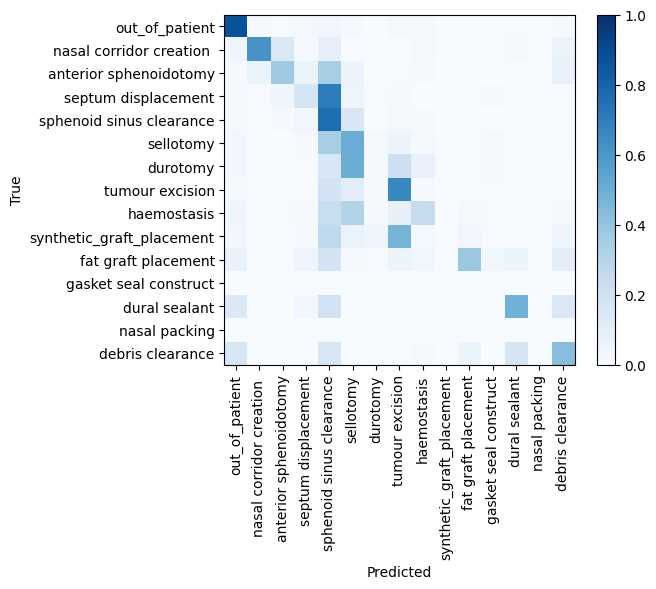

In [ ]:

import matplotlib.pyplot as plt

# cm = confusion_matrix(step_result_endofm["y_true"], step_result_endofm["pred"], normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(step_names))); ax.set_xticklabels(step_names, rotation=90)
ax.set_yticks(range(len(step_names))); ax.set_yticklabels(step_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "step_confusion_matrix.png", dpi=150)
plt.show()


In [ ]:

out = {
    "step": {
        "endofm": {"accuracy": float(step_result_endofm["accuracy"]), "macro_f1": float(step_result_endofm["macro_f1"])},
        "random_init_control": {"accuracy": float(step_result_random["accuracy"]), "macro_f1": float(step_result_random["macro_f1"])},
        "classes": all_steps,
    },
    "instrument1": {
        "endofm": {"accuracy": float(instr1_result_endofm["accuracy"]), "macro_f1": float(instr1_result_endofm["macro_f1"])},
        "random_init_control": {"accuracy": float(instr1_result_random["accuracy"]), "macro_f1": float(instr1_result_random["macro_f1"])},
        "classes": all_instr1,
    },
    "n_train_test_rows": {"train": len(train_rows), "test": len(test_rows)},
    "train_video_ids": sorted(TRAIN_VIDEO_IDS),
    "test_video_ids": sorted(TEST_VIDEO_IDS),
    "split_is_official_challenge_split": False,
}
with open(RESULTS_DIR / "benchmark_results.json", "w") as f:
    json.dump(out, f, indent=2)
print(json.dumps(out, indent=2))


{
  "step": {
    "endofm": {
      "accuracy": 0.535311324697033,
      "macro_f1": 0.3664438406387754
    },
    "random_init_control": {
      "accuracy": 0.29047229047229045,
      "macro_f1": 0.24424591205088522
    },
    "classes": [
      -1,
      1,
      2,
      3,
      4,
      5,
      6,
      7,
      8,
      9,
      10,
      11,
      12,
      13,
      14
    ]
  },
  "instrument1": {
    "endofm": {
      "accuracy": 0.3340424723625727,
      "macro_f1": 0.21881267788322925
    },
    "random_init_control": {
      "accuracy": 0.16461916461916462,
      "macro_f1": 0.14382697233355649
    },
    "classes": [
      -1,
      0,
      1,
      2,
      3,
      4,
      5,
      6,
      7,
      8,
      9,
      10,
      11,
      12,
      13,
      14,
      15,
      16,
      17,
      18
    ]
  },
  "n_train_test_rows": {
    "train": 93695,
    "test": 26323
  },
  "train_video_ids": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10

## 12. Final probes on full data

In [ ]:

import joblib
from datetime import datetime, timezone

full_feats = np.concatenate([endofm_feats["train_f"], endofm_feats["test_f"]])
full_step = np.concatenate([endofm_feats["train_ys"], endofm_feats["test_ys"]])
full_instr1 = np.concatenate([endofm_feats["train_yi1"], endofm_feats["test_yi1"]])

final_step_clf = LogisticRegression(max_iter=2000, class_weight="balanced")
final_step_clf.fit(full_feats, full_step)

final_instr1_clf = LogisticRegression(max_iter=2000, class_weight="balanced")
final_instr1_clf.fit(full_feats, full_instr1)

ARTIFACT_DIR = RESULTS_DIR / "final_model"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(final_step_clf, ARTIFACT_DIR / "step_linear_probe.joblib")
joblib.dump(final_instr1_clf, ARTIFACT_DIR / "instrument1_linear_probe.joblib")

with open(ARTIFACT_DIR / "label_mapping.json", "w") as f:
    json.dump({"steps": all_steps, "step_to_idx": step_to_idx, "instr1": all_instr1, "instr1_to_idx": instr1_to_idx,
               "step_map": step_map, "instrument_map": instrument_map}, f, indent=2)

with open(ARTIFACT_DIR / "metadata.json", "w") as f:
    json.dump({
        "backbone_checkpoint": str(CKPT_PATH),
        "feature_dim": int(full_feats.shape[1]),
        "n_training_frames": int(full_feats.shape[0]),
        "train_video_ids": sorted(TRAIN_VIDEO_IDS),
        "test_video_ids": sorted(TEST_VIDEO_IDS),
        "split_is_official_challenge_split": False,
        "saved_at_utc": datetime.now(timezone.utc).isoformat(),
    }, f, indent=2)

print("Saved:", ARTIFACT_DIR)


Saved: /content/drive/MyDrive/endofm-benchmark/results/pitvis/final_model


## Notes / caveats

- **Split is not verified against the official PitVis Challenge split** --
  it's a plain last-5-videos holdout. Replace `TEST_VIDEO_IDS` if you get
  the real challenge split.
- `-1`/similar sentinel values in step or instrument columns likely mean
  "no annotated step" or "no instrument in this slot" -- included here as
  their own class rather than filtered, since no confirmed semantics for
  them were available. Filter them yourself if that's not the right call
  for your analysis.
- `instrument2` was heavily skewed toward a single sentinel value in the
  single-video smoke test -- may be near-degenerate across the full
  dataset too; read its numbers with that in mind.
- Same frame-replication limitation as the other notebooks: no real
  temporal information is used, each frame stands alone.
- Unlike Kvasir-Capsule/Cholec80, PitVis-2023 is not in Endo-FM's
  pretraining corpus -- this is a genuinely clean generalization test.
